<a href="https://colab.research.google.com/github/abdullaawad/Medical-Insurance-Project/blob/main/Medical_Insurance_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kaggle --quiet

In [2]:
from google.colab import files
files.upload()  # upload kaggle.json

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"abdullahismailawad","key":"5b68d42de473795ac78850a555e69a2b"}'}

In [3]:
import os

os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.kaggle/kaggle.json')

os.chmod('/root/.kaggle/kaggle.json', 600)

In [4]:
!kaggle datasets download rahulvyasm/medical-insurance-cost-prediction

Dataset URL: https://www.kaggle.com/datasets/rahulvyasm/medical-insurance-cost-prediction
License(s): MIT
100% 31.6k/31.6k [00:00<00:00, 40.6MB/s]



In [5]:
!unzip medical-insurance-cost-prediction.zip

Archive:  medical-insurance-cost-prediction.zip
  inflating: medical_insurance.csv   


# **Problem Statement:**

## What are the primary factors influencing medical expenses?



## How accurate are machine learning models in predicting medical expenses?



## In what ways can machine learning models enhance the efficiency and profitability of health insurance companies?

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [7]:
df = pd.read_csv('/content/medical-insurance-cost-prediction.zip')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   int64  
 1   sex       2772 non-null   object 
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2772 non-null   object 
 5   region    2772 non-null   object 
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 151.7+ KB


In [9]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [10]:
df.describe()

,age,bmi,children,charges
count,2772.000000,2772.000000,2772.000000,2772.000000
mean,39.109668,30.701349,1.101732,13261.369959
std,14.081459,6.129449,1.214806,12151.768945
min,18.000000,15.960000,0.000000,1121.873900
25%,26.000000,26.220000,0.000000,4687.797000
50%,39.000000,30.447500,1.000000,9333.014350
75%,51.000000,34.770000,2.000000,16577.779500
max,64.000000,53.130000,5.000000,63770.428010


## **What are the primary factors influencing medical expenses?**

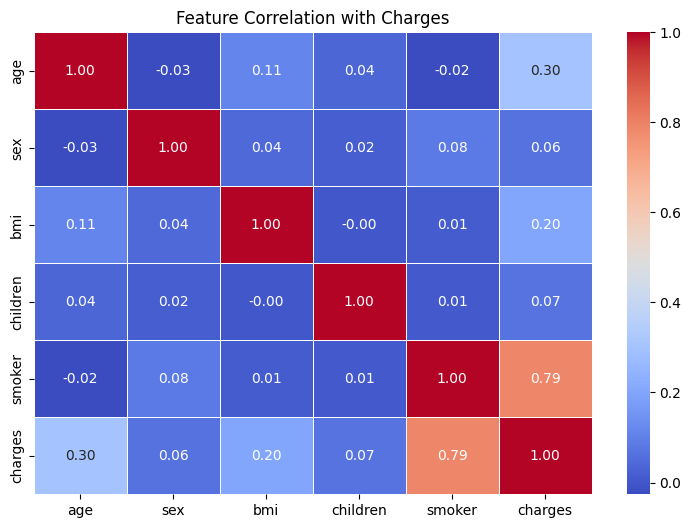

In [11]:
corr = df.copy()
corr['smoker'] = corr['smoker'].map({'yes': 1, 'no': 0})
corr['sex'] = corr['sex'].map({'male': 1, 'female': 0})

plt.figure(figsize=(9, 6))
sns.heatmap(corr.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation with Charges')
plt.show()

## **The correlation heatmap shows 'smoker' & 'age' as the factors with the highest correlation to 'charges'**

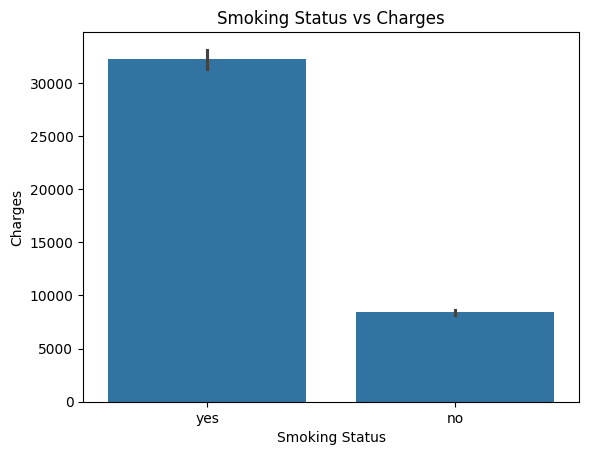

In [12]:
sns.barplot(x='smoker', y='charges', data=df)
plt.xlabel('Smoking Status')
plt.ylabel('Charges')
plt.title('Smoking Status vs Charges')
plt.show()

In [13]:
avg_charges_smoker = df.groupby('smoker')['charges'].mean()
avg_charges_smoker

,charges
smoker,
no,8417.874411
yes,32223.139764


## **Age:**

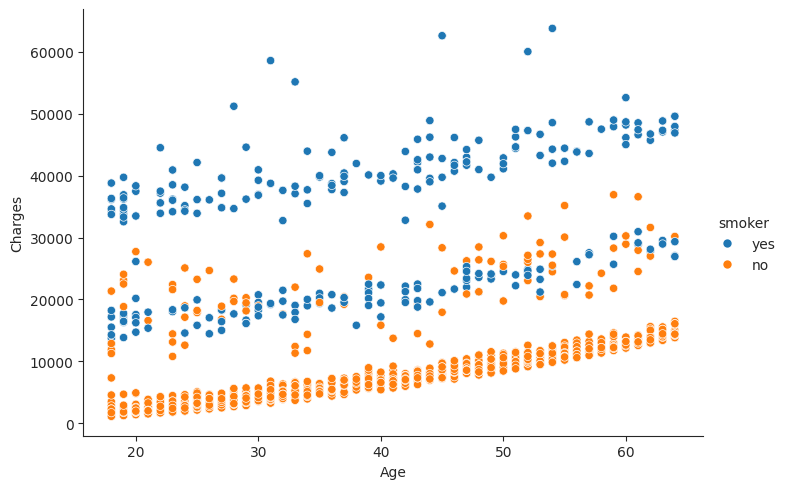

In [14]:
sns.set_style('ticks')
scatter_plot = sns.relplot(x='age', y='charges', data=df, kind='scatter', hue='smoker', height=5, aspect=1.45)
scatter_plot.set_axis_labels('Age', 'Charges')
plt.show()

Text(0.5, 0.98, 'BMI vs Charges')

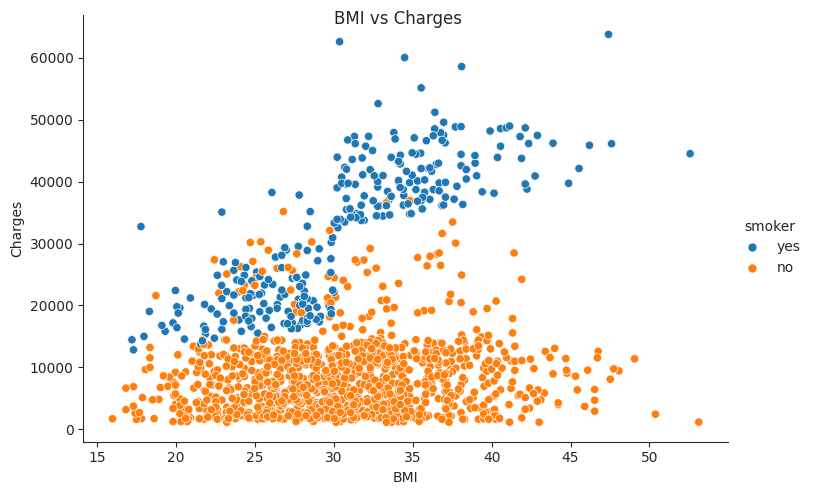

In [15]:
bmi_plot = sns.relplot(data=df, x='bmi', y='charges', kind='scatter', hue='smoker', color='r', height=5, aspect=1.5)
bmi_plot.set_axis_labels('BMI', 'Charges')
bmi_plot.fig.suptitle('BMI vs Charges')

# **Outlier detection & removal:**

In [16]:
age_outliers = px.box(df, x='age')
age_outliers.show()

In [17]:
bmi_outliers = px.box(df, x='bmi')
bmi_outliers.show()

In [18]:
# There are only 7 instances greater than the upper fence value, so I removed them

df.drop(df[df['bmi'] > 47.52].index, inplace=True)

In [19]:
# There is a large number of outliers, however, these are real and unusual medical insurance prices
# Therefore, I will not remove any charge outliers

charges_outliers = px.box(df, x='charges')
charges_outliers.show()

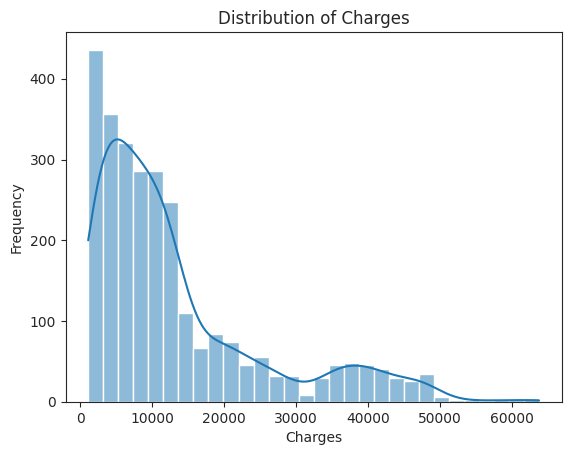

In [20]:
sns.histplot(df['charges'], kde=True, bins=30)
plt.xlabel('Charges')
plt.ylabel('Frequency')
plt.title('Distribution of Charges')
plt.show()

## **Sex**

In [21]:
sex_distribution = px.histogram(df, x='sex')
sex_distribution

In [22]:
avg_charges_per_region = df.groupby('region')['charges'].mean()
avg_charges_per_region

,charges
region,
northeast,13488.200803
northwest,12463.129315
southeast,14760.710871
southwest,12064.638327


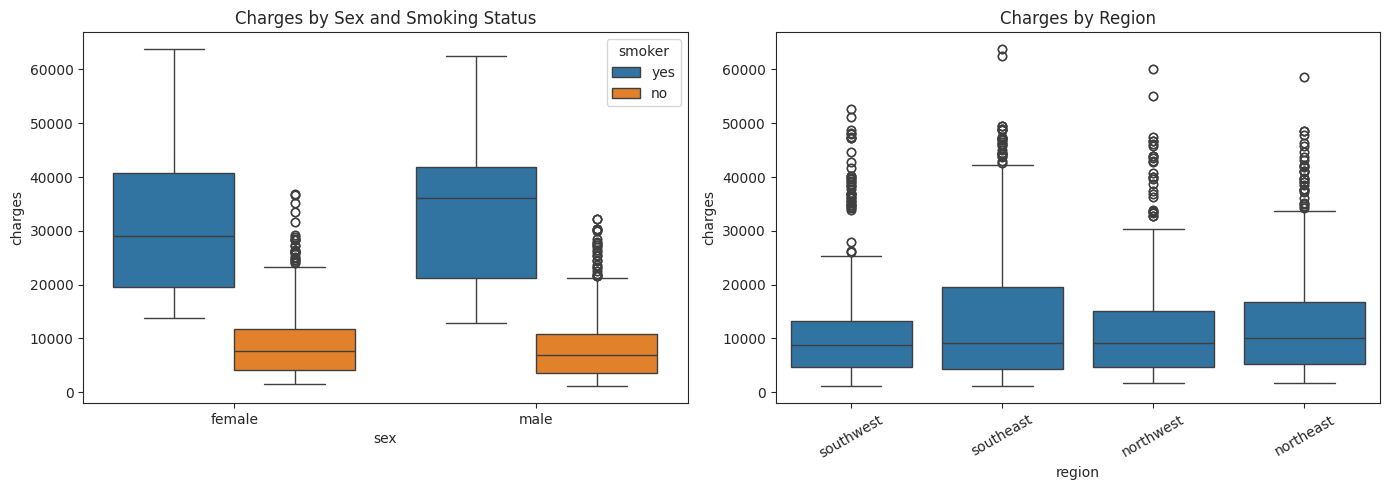

In [25]:
# The first plot reveals the significance being a smoker has on charges.
# Charge outliers in non-smokers are on par with median and 75% quartile range values in smokers.

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='sex', y='charges', hue='smoker', data=df, ax=ax[0])
ax[0].set_title('Charges by Sex and Smoking Status')

sns.boxplot(x='region', y='charges', data=df, ax=ax[1])
ax[1].set_title('Charges by Region')
ax[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

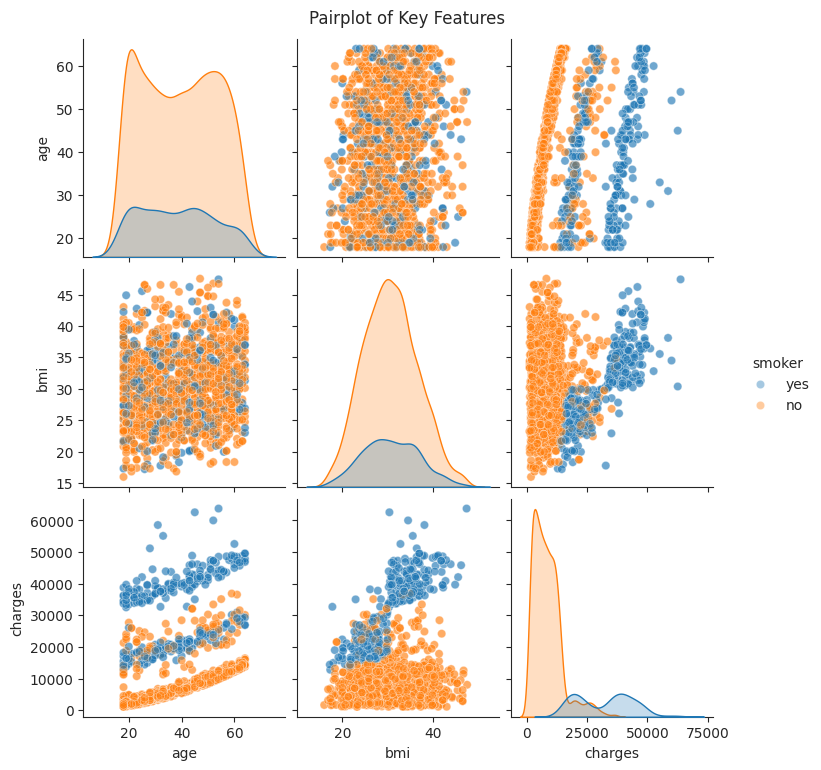

In [26]:
sns.pairplot(df[['age', 'bmi', 'charges', 'smoker']], hue='smoker', plot_kws={'alpha': 0.4})
plt.suptitle('Pairplot of Key Features', y=1.02)
plt.show()

# **Implementing Machine Learning Algorithms:**

In [27]:
from sklearn import preprocessing
label_encoder = preprocessing.LabelEncoder()

label_encoder = preprocessing.LabelEncoder()
df['sex']= label_encoder.fit_transform(df['sex'])

df['smoker']= label_encoder.fit_transform(df['smoker'])

df['region']= label_encoder.fit_transform(df['region'])

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('charges', axis=1)
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=20, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
age,2758.0,39.122553,14.076693,18.0000,26.000000,39.00000,51.000000,64.00000
sex,2758.0,0.506164,0.500053,0.0000,0.000000,1.00000,1.000000,1.00000
bmi,2758.0,30.604431,5.989770,15.9600,26.205000,30.40000,34.656250,47.52000
children,2758.0,1.102248,1.216673,0.0000,0.000000,1.00000,2.000000,5.00000
smoker,2758.0,0.203046,0.402339,0.0000,0.000000,0.00000,0.000000,1.00000
region,2758.0,1.530819,1.104428,0.0000,1.000000,2.00000,2.000000,3.00000
charges,2758.0,13238.200997,12112.415029,1121.8739,4695.398637,9301.89355,16547.261588,63770.42801


In [29]:
print('Whole Data Shape', df.shape)
print('Training Data Shape', X_train.shape)
print('Testing Data Shape', X_test.shape)

Whole Data Shape (2758, 7)
Training Data Shape (1379, 6)
Testing Data Shape (1379, 6)


# **k-NN:**

In [31]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model_knn = KNeighborsRegressor()
model_knn.fit(X_train, y_train)

y_pred = model_knn.predict(X_test)

mae_knn = mean_absolute_error(y_test, y_pred)
mse_knn = mean_squared_error(y_test, y_pred)
r2_knn = r2_score(y_test, y_pred)

print('Mean Absolute Error:', mae_knn)
print('Mean Squared Error:', mse_knn)
print('R-squared:', r2_knn)

Mean Absolute Error: 2467.0403143064536
Mean Squared Error: 17395534.366802055
R-squared: 0.8813865922905805


In [32]:
print(f"R² Score: {r2_knn:.4f}  — the model explains {r2_knn*100:.1f}% of variance in charges")
print(f"MAE: £{mae_knn:,.2f}  — on average, predictions are off by this amount")
print(f"RMSE: £{np.sqrt(mse_knn):,.2f}  — penalises large errors more heavily than MAE")

R² Score: 0.8814  — the model explains 88.1% of variance in charges
MAE: £2,467.04  — on average, predictions are off by this amount
RMSE: £4,170.80  — penalises large errors more heavily than MAE


In [33]:
data = []
data.append( {"age":56.0,
              "sex":1,
              "bmi":29,
              "children":3,
              "smoker":0,
              "region":2} )
df2 = pd.DataFrame(data)


df2["Predicted Medical Insurance Charge"] = model_knn.predict(df2)
df2.head()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning:

X has feature names, but KNeighborsRegressor was fitted without feature names



,age,sex,bmi,children,smoker,region,Predicted Medical Insurance Charge
0,56.0,1,29,3,0,2,13953.71601


# **Random Forest Regressor:**

In [35]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

model_rf = RandomForestRegressor()
model_rf.fit(X_train, y_train)

y_pred2 = model_rf.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred2)
mae_rf = mean_absolute_error(y_test, y_pred2)
r2_rf = r2_score(y_test, y_pred2)

print('Mean Squared Error:', mse_rf)
print('Mean Absolute Error:', mae_rf)
print('R-squared:', r2_rf)

Mean Squared Error: 3174096.70080213
Mean Absolute Error: 945.5555849387489
R-squared: 0.9783570646268925


In [36]:
print(f"R² Score: {r2_rf:.4f}  — the model explains {r2_rf*100:.1f}% of variance in charges")
print(f"MAE: £{mae_rf:,.2f}  — on average, predictions are off by this amount")
print(f"RMSE: £{np.sqrt(mse_rf):,.2f}  — penalises large errors more heavily than MAE")

R² Score: 0.9784  — the model explains 97.8% of variance in charges
MAE: £945.56  — on average, predictions are off by this amount
RMSE: £1,781.60  — penalises large errors more heavily than MAE


# **Decision Tree:**

In [37]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model_dt = DecisionTreeRegressor()
model_dt.fit(X_train, y_train)

y_pred3 = model_dt.predict(X_test)

mae_dt = mean_absolute_error(y_test, y_pred3)
mse_dt = mean_squared_error(y_test, y_pred3)
r2_dt = r2_score(y_test, y_pred3)

print('Mean Absolute Error:', mae_dt)
print('Mean Squared Error:', mse_dt)
print('R-squared:', r2_dt)

Mean Absolute Error: 22.94604162436548
Mean Squared Error: 189511.47439383843
R-squared: 0.9987077946958164


In [38]:
print(f"R² Score: {r2_dt:.4f}  — the model explains {r2_dt*100:.1f}% of variance in charges")
print(f"MAE: £{mae_dt:,.2f}  — on average, predictions are off by this amount")
print(f"RMSE: £{np.sqrt(mse_dt):,.2f}  — penalises large errors more heavily than MAE")

R² Score: 0.9987  — the model explains 99.9% of variance in charges
MAE: £22.95  — on average, predictions are off by this amount
RMSE: £435.33  — penalises large errors more heavily than MAE


In [39]:
print("The full Regression Decision Tree Levels: ", model_dt.tree_.max_depth)

The full Regression Decision Tree Levels:  20


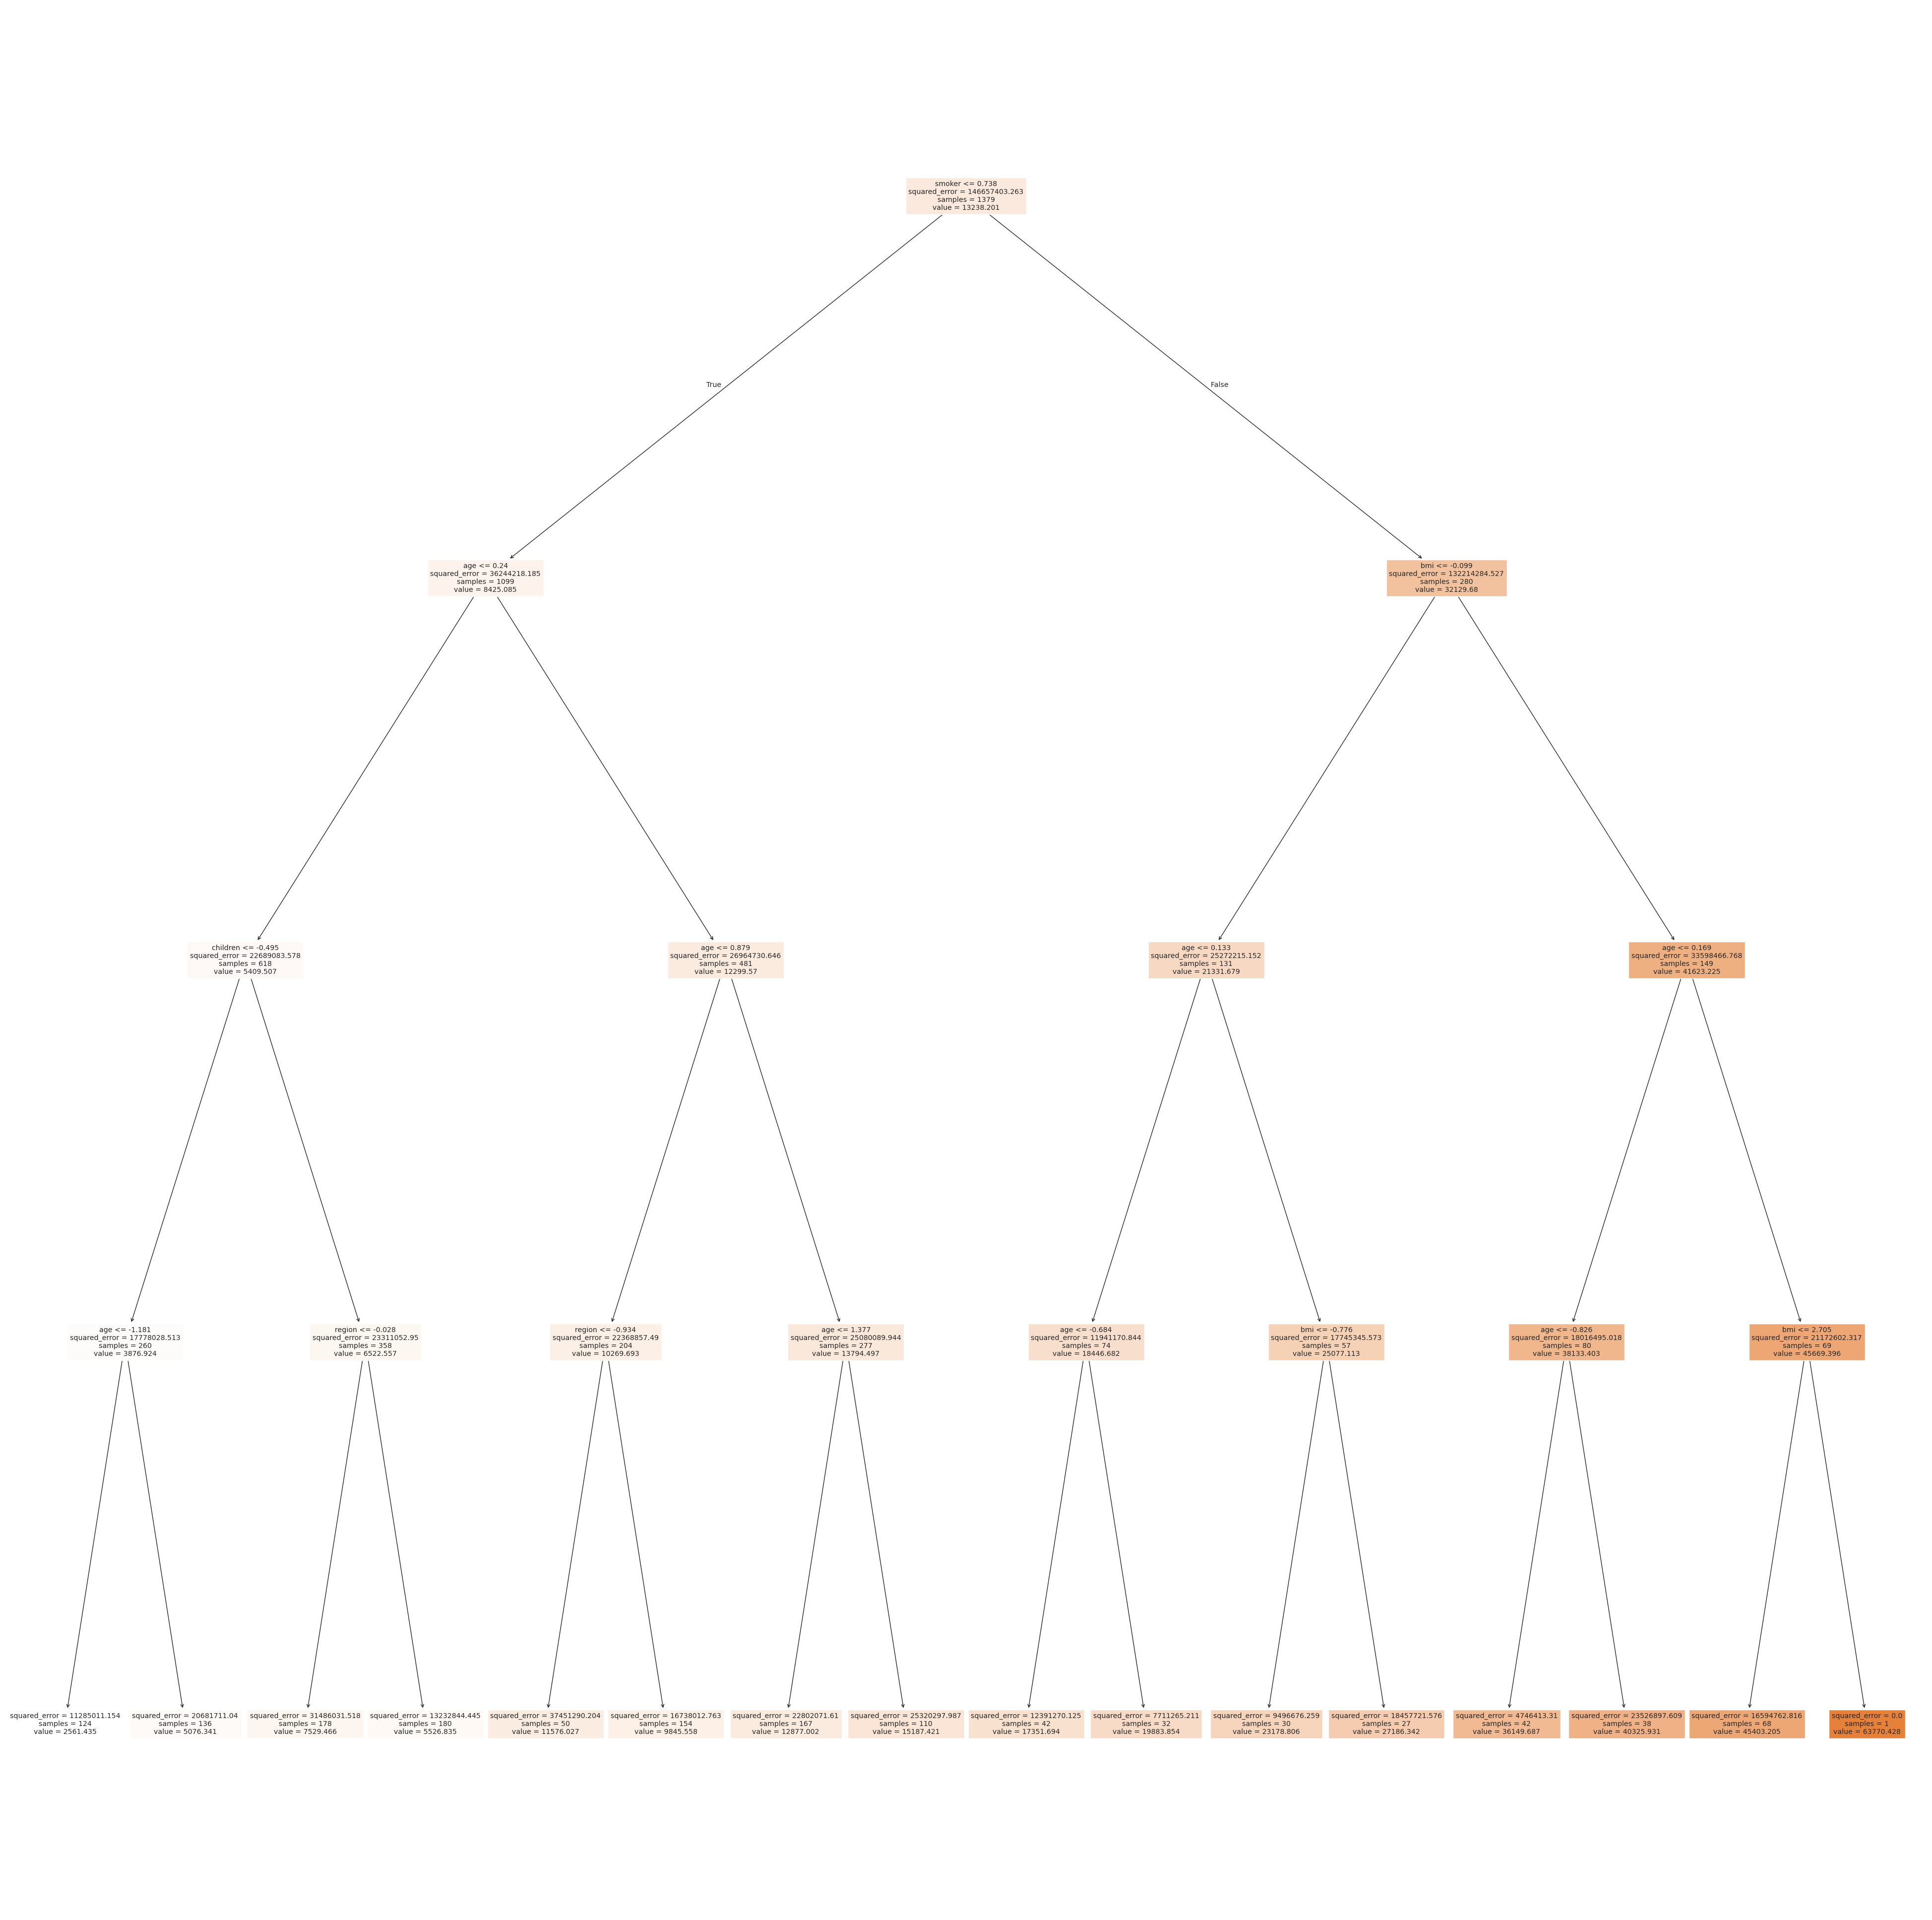

In [40]:
from sklearn.tree import plot_tree
pruned_regressor = DecisionTreeRegressor(max_depth=4)
pruned_regressor.fit(X_train, y_train)


y_pred_pruned = pruned_regressor.predict(X_test)


pruned_Tree_model = plt.figure(figsize=(50,50))
pruned_Tree_model_Graph = plot_tree(pruned_regressor, feature_names=list(X.columns), filled=True)


pruned_Tree_model.savefig("pruned_reg_decision_tree.png")

In [41]:
data = []
data.append( {"age":56.0,
              "sex":1,
              "bmi":29,
              "children":3,
              "smoker":0,
              "region":2} )
df2 = pd.DataFrame(data)


df2["Predicted Medical Insurance Charge"] = pruned_regressor.predict(df2)
df2.head()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning:

X has feature names, but DecisionTreeRegressor was fitted without feature names



,age,sex,bmi,children,smoker,region,Predicted Medical Insurance Charge
0,56.0,1,29,3,0,2,15187.421285


# **XGBoost:**

In [42]:
from xgboost import XGBRegressor
xgb_model = XGBRegressor()

xgb_model.fit(X_train, y_train)

y_pred4 = xgb_model.predict(X_test)

mae_xg = mean_absolute_error(y_test, y_pred4)
mse_xg = mean_squared_error(y_test, y_pred4)
r2_xg = r2_score(y_test, y_pred4)

print('Mean Absolute Error:', mae_xg)
print('Mean Squared Error:', mse_xg)
print('R-squared:', r2_xg)

Mean Absolute Error: 584.2885537813831
Mean Squared Error: 1118210.8392968632
R-squared: 0.9923753536172057


In [43]:
print(f"R² Score: {r2_xg:.4f}  — the model explains {r2_xg*100:.1f}% of variance in charges")
print(f"MAE: £{mae_xg:,.2f}  — on average, predictions are off by this amount")
print(f"RMSE: £{np.sqrt(mse_xg):,.2f}  — penalises large errors more heavily than MAE")

R² Score: 0.9924  — the model explains 99.2% of variance in charges
MAE: £584.29  — on average, predictions are off by this amount
RMSE: £1,057.45  — penalises large errors more heavily than MAE


### **XGBoost GridSearchCV Hyperparameter Tuning:**

In [44]:
params_xgb = {
    'n_estimators' : [100, 200, 300],
    'max_depth' : [3, 6, 9],
    'learning_rate' : [0.01, 0.1, 0.2],
    'gamma' : [0, 0.1, 0.2]
}

In [45]:
from sklearn.model_selection import GridSearchCV
xgb_gs = GridSearchCV(xgb_model, params_xgb, cv=5, n_jobs=-1)
xgb_gs.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None...
                                    max_cat_threshold=None,
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'gamma': [0, 0.1, 0.2],
                         'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 6, 9],
                         'n_estimators': [100, 200, 300]})

In [46]:
print(xgb_gs.best_estimator_)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)


In [47]:
xgb_gs.best_estimator_.fit(X_train, y_train)
y_pred5 = xgb_gs.best_estimator_.predict(X_test)

mae_xgb_tuned = mean_absolute_error(y_test, y_pred5)
mse_xgb_tuned = mean_squared_error(y_test, y_pred5)
r2_xgb_tuned = r2_score(y_test, y_pred5)

print('Mean Absolute Error:', mae_xgb_tuned)
print('Mean Squared Error:', mse_xgb_tuned)
print('R-squared:', r2_xgb_tuned)

Mean Absolute Error: 2153.198203750762
Mean Squared Error: 15751273.710796176
R-squared: 0.8925981685180739


In [48]:
print(f"R² Score: {r2_xgb_tuned:.4f}  — the model explains {r2_xgb_tuned*100:.1f}% of variance in charges")
print(f"MAE: £{mae_xgb_tuned:,.2f}  — on average, predictions are off by this amount")
print(f"RMSE: £{np.sqrt(mse_xgb_tuned):,.2f}  — penalises large errors more heavily than MAE")

R² Score: 0.8926  — the model explains 89.3% of variance in charges
MAE: £2,153.20  — on average, predictions are off by this amount
RMSE: £3,968.79  — penalises large errors more heavily than MAE


In [73]:
results = pd.DataFrame({
    'Model': ['k-NN', 'Random Forest', 'Decision Tree', 'XGBoost', 'XGBoost (tuned)'],
    'MAE': [mae_knn, mae_rf, mae_dt, mae_xg, mae_xgb_tuned],
    'RMSE': [mse_knn, mse_rf, mse_dt, mse_xg, mse_xgb_tuned],
    'R²': [r2_knn, r2_rf, r2_dt, r2_xg, r2_xgb_tuned]
}).sort_values('R²', ascending=False)

results.style.background_gradient(cmap='RdYlGn', subset=['R²'])


,Model,MAE,RMSE,R²
2,Decision Tree,22.946042,189511.474394,0.998708
3,XGBoost,584.288554,1118210.839297,0.992375
1,Random Forest,945.555585,3174096.700802,0.978357
4,XGBoost (tuned),2153.198204,15751273.710796,0.892598
0,k-NN,2467.040314,17395534.366802,0.881387


/tmp/ipykernel_5643/833058868.py:5: FutureWarning:



Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#750851'` for the same effect.


/tmp/ipykernel_5643/833058868.py:11: FutureWarning:



Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#3eaf76'` for the same effect.


/tmp/ipykernel_5643/833058868.py:17: FutureWarning:



Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#0e87cc'` for the same effect.




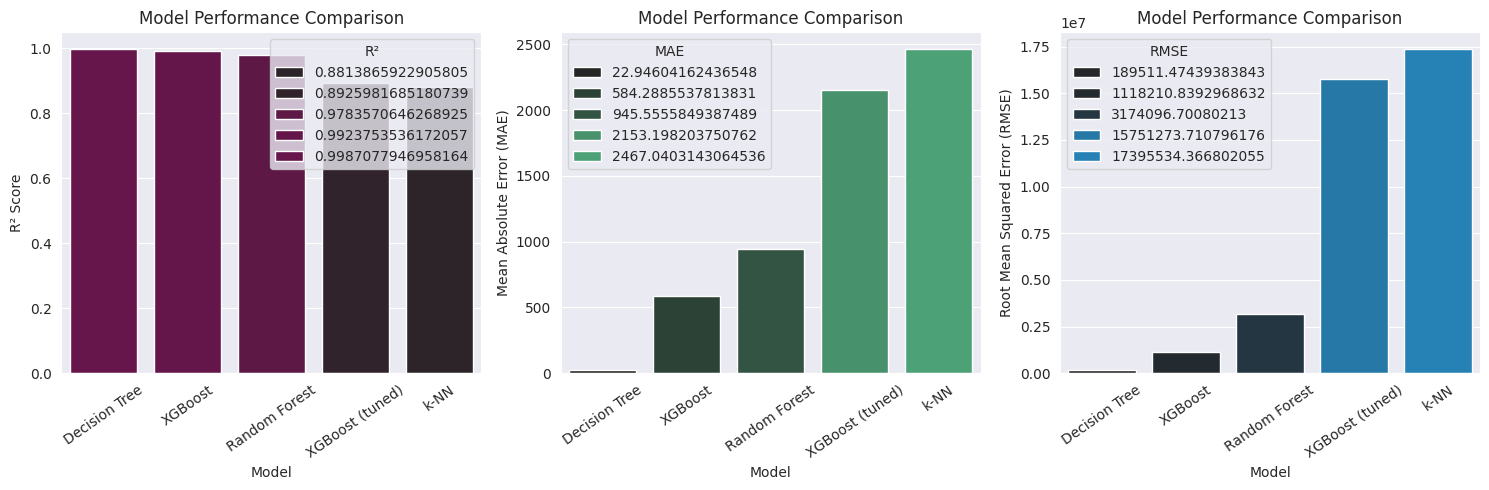

In [77]:
sns.set_palette('pastel')
sns.set_style('darkgrid')
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

sns.barplot(x='Model', y='R²', data=results, ax=ax[0], hue='R²', color=sns.xkcd_rgb['velvet'])
ax[0].set_xlabel('Model')
ax[0].set_ylabel('R² Score')
ax[0].set_title('Model Performance Comparison')
ax[0].tick_params(axis='x', rotation=35)

sns.barplot(x='Model', y='MAE', data=results, ax=ax[1], hue='MAE', color=sns.xkcd_rgb['dark seafoam green'])
ax[1].set_xlabel('Model')
ax[1].set_ylabel('Mean Absolute Error (MAE)')
ax[1].set_title('Model Performance Comparison')
ax[1].tick_params(axis='x', rotation=35)

sns.barplot(x='Model', y='RMSE', data=results, ax=ax[2], hue='RMSE', color=sns.xkcd_rgb['water blue'])
ax[2].set_xlabel('Model')
ax[2].set_ylabel('Root Mean Squared Error (RMSE)')
ax[2].set_title('Model Performance Comparison')
ax[2].tick_params(axis='x', rotation=35)


plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred5, alpha=0.4, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect prediction')
plt.xlabel('Actual Charges (£)')
plt.ylabel('Predicted Charges (£)')
plt.title('XGBoost (Tuned): Actual vs Predicted')
plt.legend()
plt.show()

In [ ]:
# Prediction with pre-tuned XGBoost model
data = []
data.append( {"age":56.0,
              "sex":1,
              "bmi":29,
              "children":3,
              "smoker":0,
              "region":2} )
df3 = pd.DataFrame(data)


df3["Predicted Medical Insurance Charge"] = xgb_model.predict(df3)
df3.head()

In [ ]:
# Prediction with GridSearchCV hypertuned parameters
data = []
data.append( {"age":56.0,
              "sex":1,
              "bmi":29,
              "children":3,
              "smoker":0,
              "region":2} )
df2 = pd.DataFrame(data)


df2["Predicted Medical Insurance Charge"] = xgb_gs.predict(df2)
df2.head()